[CO Initialised]
 [train] Training model for submeter dish washer
 [train_on_chunk] Done training!
 [train] Training model for submeter electric space heater
 [train_on_chunk] Done training!
 [train] Training model for submeter electric stove
 [train_on_chunk] Done training!
 [train] Training model for submeter fridge
 [train_on_chunk] Done training!
 [train] Training model for submeter microwave
 [train_on_chunk] Done training!
 [train] Training model for submeter washer dryer
 [train_on_chunk] Done training!
Estimating power demand for 'dish washer'
Estimating power demand for 'electric space heater'
Estimating power demand for 'electric stove'
Estimating power demand for 'fridge'
Estimating power demand for 'microwave'
Estimating power demand for 'washer dryer'

Presnosť disaggregácie (house1_6):
MAE: 190.82 W
MSE: 452686.52 W^2
RMSE: 672.82 W

Spotrebiče (house1_6):
               Spotrebič  Skutočná spotreba (Wh)  Predikovaná spotreba (Wh)
0            dish washer                 

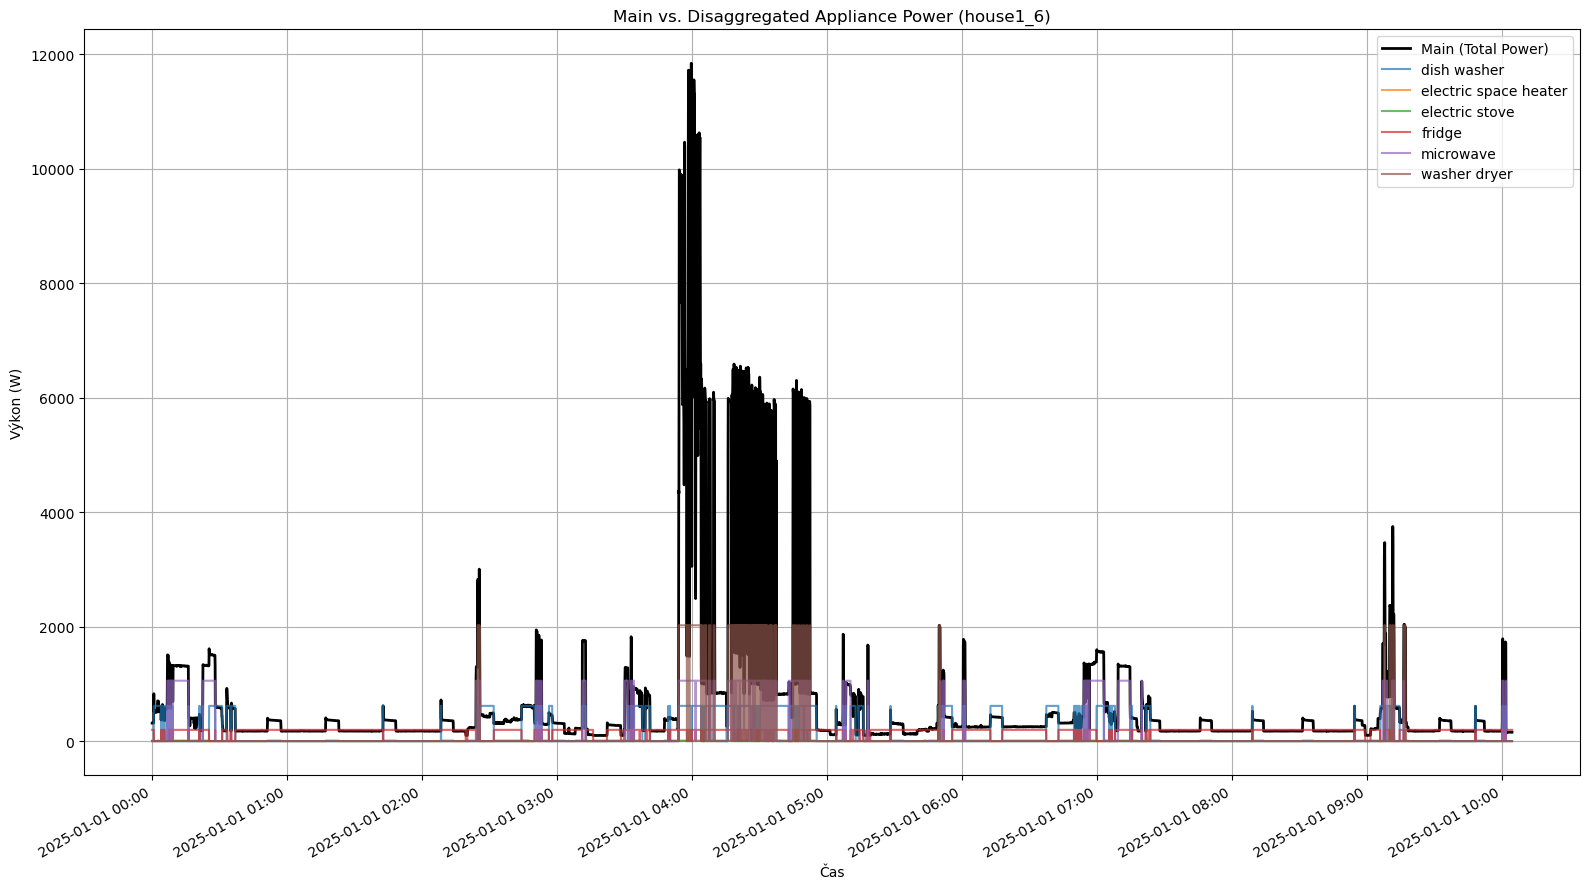

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime, timedelta
from co_model import CO  

# 1. Načítanie a predspracovanie trénovacích datasetov 0 až 5 
datasets = []
for i in range(6):
    df = pd.read_csv(f"standardized_house1_{i}.csv")
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['power'] = df['main']
    datasets.append(df)

# 2. Spojenie do jedného trénovacieho datasetu
df_train = pd.concat(datasets, ignore_index=True)
appliance_list = [col for col in df_train.columns if col not in ['timestamp', 'main', 'power']]

# 3. Trénovanie modelu
model1 = CO(debug=True)
model1.train(df_train, appliance_list)

# 4. Načítanie testovacieho datasetu house1_6 (už downsamplovaný)
df_6_down = pd.read_csv("standardized_house1_6.csv")
df_6_down['timestamp'] = pd.to_datetime(df_6_down['timestamp'])
df_6_down['power'] = df_6_down['main']

# 5. Disaggregácia
disaggregated_df = model1.disaggregate(df_6_down)

# 6. Výpočet presnosti
sum_disagg = disaggregated_df.sum(axis=1)
residual = df_6_down['main'] - sum_disagg

mae = mean_absolute_error(df_6_down['main'], sum_disagg)
mse = mean_squared_error(df_6_down['main'], sum_disagg)
rmse = np.sqrt(mse)

print("\nPresnosť disaggregácie (house1_6):")
print(f"MAE: {mae:.2f} W")
print(f"MSE: {mse:.2f} W^2")
print(f"RMSE: {rmse:.2f} W")


appliance_stats_df = pd.DataFrame(appliance_stats)
print("\nSpotrebiče (house1_6):")
print(appliance_stats_df)

# 8. Vizualizácia: Main vs. disaggregované (s timestampom na osi X)
import matplotlib.dates as mdates

plt.figure(figsize=(16, 9))
plt.plot(df_6_down['timestamp'], df_6_down['main'], label='Main (Total Power)', color='black', linewidth=2)
for col in disaggregated_df.columns:
    plt.plot(df_6_down['timestamp'], disaggregated_df[col], label=col, alpha=0.7)

plt.title("Main vs. Disaggregated Appliance Power (house1_6)")
plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.legend()
plt.grid(True)

# Časová os vo formáte YYYY-MM-DD HH:MM
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

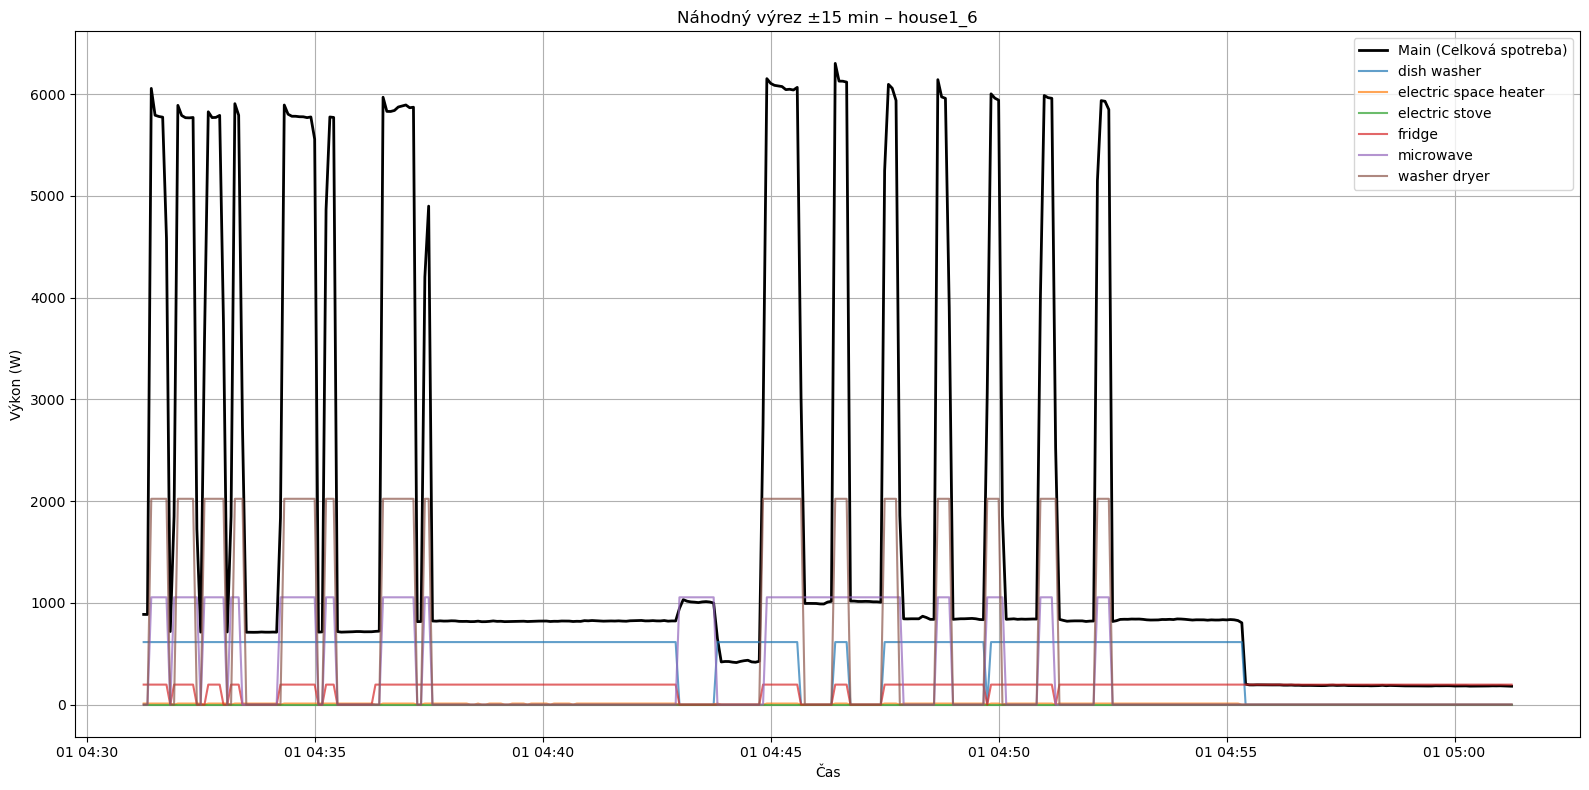

In [54]:
import random

# Výrez okolo náhodného času (±15 minút)
random_index = random.randint(0, len(df_6_down) - 1)
random_time = df_6_down.loc[random_index, 'timestamp']

start_window = random_time - pd.Timedelta(minutes=15)
end_window = random_time + pd.Timedelta(minutes=15)

# Výber dát vo výreze
mask_window = (df_6_down['timestamp'] >= start_window) & (df_6_down['timestamp'] <= end_window)
df_window = df_6_down[mask_window].copy()
disagg_window = disaggregated_df[mask_window.values].copy()
disagg_window['timestamp'] = df_window['timestamp'].values

# Vizualizácia
plt.figure(figsize=(16, 8))
plt.plot(df_window['timestamp'], df_window['main'], label='Main (Celková spotreba)', color='black', linewidth=2)
for col in disagg_window.columns.drop('timestamp'):
    plt.plot(disagg_window['timestamp'], disagg_window[col], label=col, alpha=0.7)


plt.title("Náhodný výrez ±15 min – house1_6")
plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Estimating power demand for 'dish washer'
Estimating power demand for 'electric space heater'
Estimating power demand for 'electric stove'
Estimating power demand for 'fridge'
Estimating power demand for 'microwave'
Estimating power demand for 'washer dryer'

📈 Výsledky disaggregácie na 'data.json':
MAE: 50.49 W
MSE: 3863.18 W²
RMSE: 62.15 W

📋 Štatistiky pre identifikované spotrebiče v 'data.json':
               Spotrebič  Spotreba energie (Wh)
0            dish washer               19885.00
1  electric space heater                3382.50
2         electric stove                   0.00
3                 fridge              100456.53
4              microwave               13926.00
5           washer dryer               36076.83


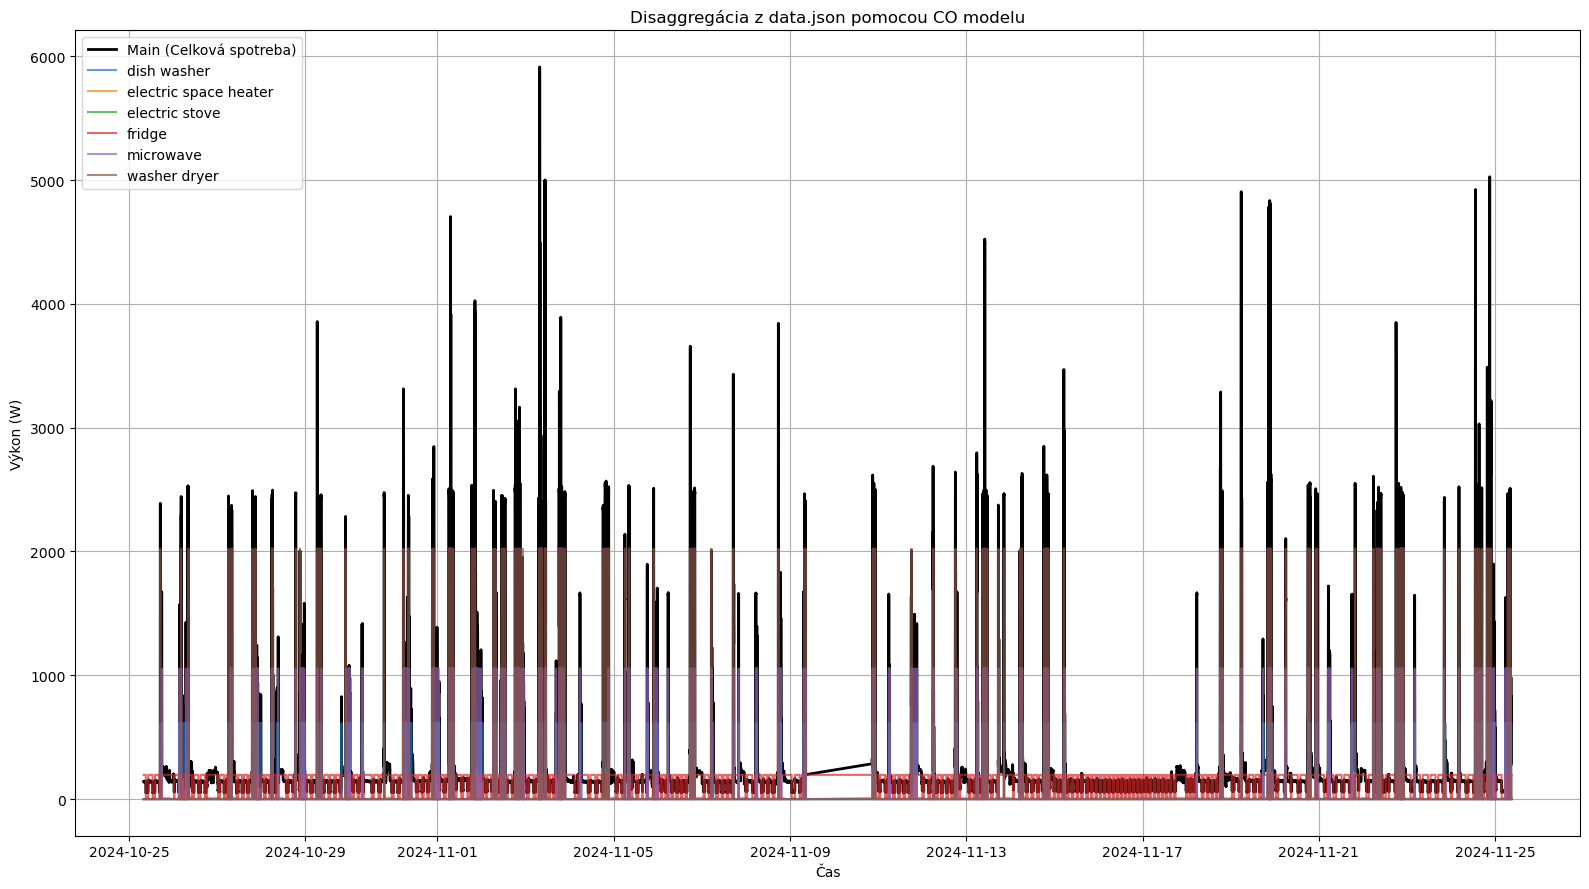

In [6]:
import json

# Načítanie JSON datasetu
with open("data.json", "r") as f:
    json_data = json.load(f)

# Prevod JSON do DataFrame
data_list = json_data['data']
df_test = pd.DataFrame([{
    'timestamp': datetime.fromtimestamp(entry['timestamp']),
    'main': entry['P']['L1']
} for entry in data_list])

# Pridanie stĺpca 'power' 
df_test['power'] = df_test['main']

# Disaggregácia pomocou natrénovaného CO modelu
disaggregated_test_df = model1.disaggregate(df_test)

# Overenie výstupu
if disaggregated_test_df is None:
    raise ValueError("Disaggregácia zlyhala – skontroluj vstupné dáta alebo model.")

# Výpočet presnosti
sum_disagg_test = disaggregated_test_df.sum(axis=1)
mae_test = mean_absolute_error(df_test['main'], sum_disagg_test)
mse_test = mean_squared_error(df_test['main'], sum_disagg_test)
rmse_test = np.sqrt(mse_test)


print("\n📈 Výsledky disaggregácie na 'data.json':")
print(f"MAE: {mae_test:.2f} W")
print(f"MSE: {mse_test:.2f} W²")
print(f"RMSE: {rmse_test:.2f} W")


# Výpočet štatistík pre každý spotrebič
sample_interval_seconds = (df_test['timestamp'].iloc[1] - df_test['timestamp'].iloc[0]).total_seconds()
seconds_to_hours = sample_interval_seconds / 3600

appliance_stats_test = []
for appliance in disaggregated_test_df.columns:
    power_series = disaggregated_test_df[appliance]
    binary_on = power_series > 10
    starts = np.sum(np.diff(binary_on.astype(int)) == 1)
    energy_Wh = power_series.sum() * seconds_to_hours
    time_on_hours = binary_on.sum() * seconds_to_hours

    appliance_stats_test.append({
        "Spotrebič": appliance,
        "Spotreba energie (Wh)": round(energy_Wh, 2),
        "Počet zapnutí": int(starts),
        "Čas zapnutia spolu (hod)": round(time_on_hours, 3)
    })

appliance_stats_test_df = pd.DataFrame(appliance_stats_test)
print("\n📋 Štatistiky pre identifikované spotrebiče v 'data.json':")
print(appliance_stats_test_df)

# Vizualizácia disaggregácie
plt.figure(figsize=(16, 9))
plt.plot(df_test['timestamp'], df_test['main'], label='Main (Celková spotreba)', color='black', linewidth=2)
for col in disaggregated_test_df.columns:
    plt.plot(df_test['timestamp'], disaggregated_test_df[col], label=col, alpha=0.7)

plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.title("Disaggregácia z data.json pomocou CO modelu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

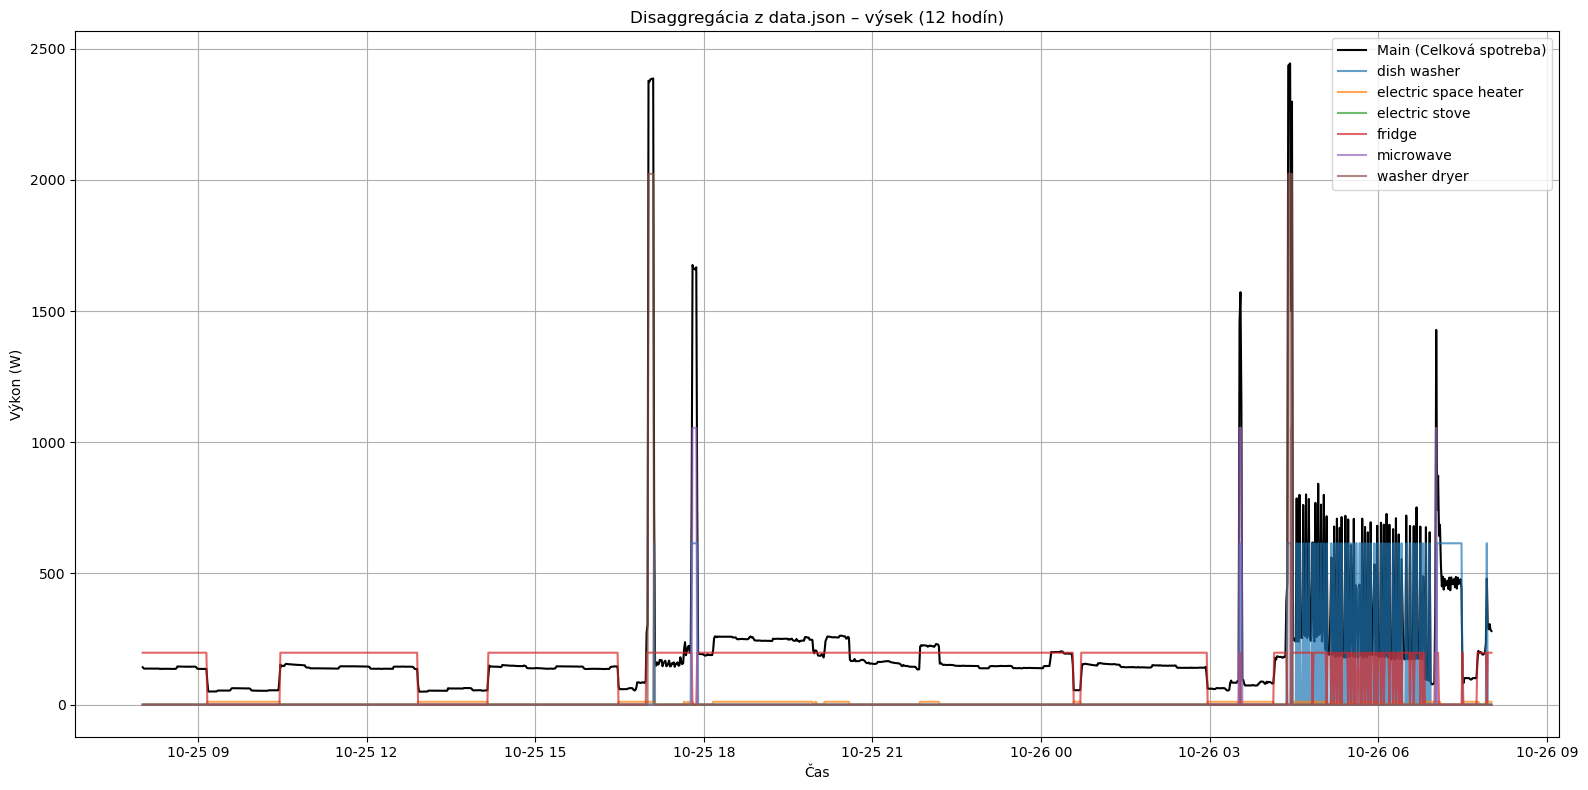

In [59]:
# Výber časového intervalu (napr. 0.5 dňa = 12 hodín)
start_time_2d = df_test['timestamp'].min()
end_time_2d = start_time_2d + pd.Timedelta(days= 1)

# Výber výseku dát
mask_2day = (df_test['timestamp'] >= start_time_2d) & (df_test['timestamp'] <= end_time_2d)
df_2day = df_test[mask_2day].copy()
disaggregated_2day = disaggregated_test_df[mask_2day.values].copy()

# Pridanie timestampu pre disaggregované dáta
disaggregated_2day['timestamp'] = df_2day['timestamp'].values

# Vizualizácia výseku
plt.figure(figsize=(16, 8))
plt.plot(df_2day['timestamp'], df_2day['main'], label='Main (Celková spotreba)', color='black')
for col in disaggregated_2day.columns.drop('timestamp'):                                                             
    plt.plot(disaggregated_2day['timestamp'], disaggregated_2day[col], label=col, alpha=0.7)

plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('Disaggregácia z data.json – výsek (12 hodín)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

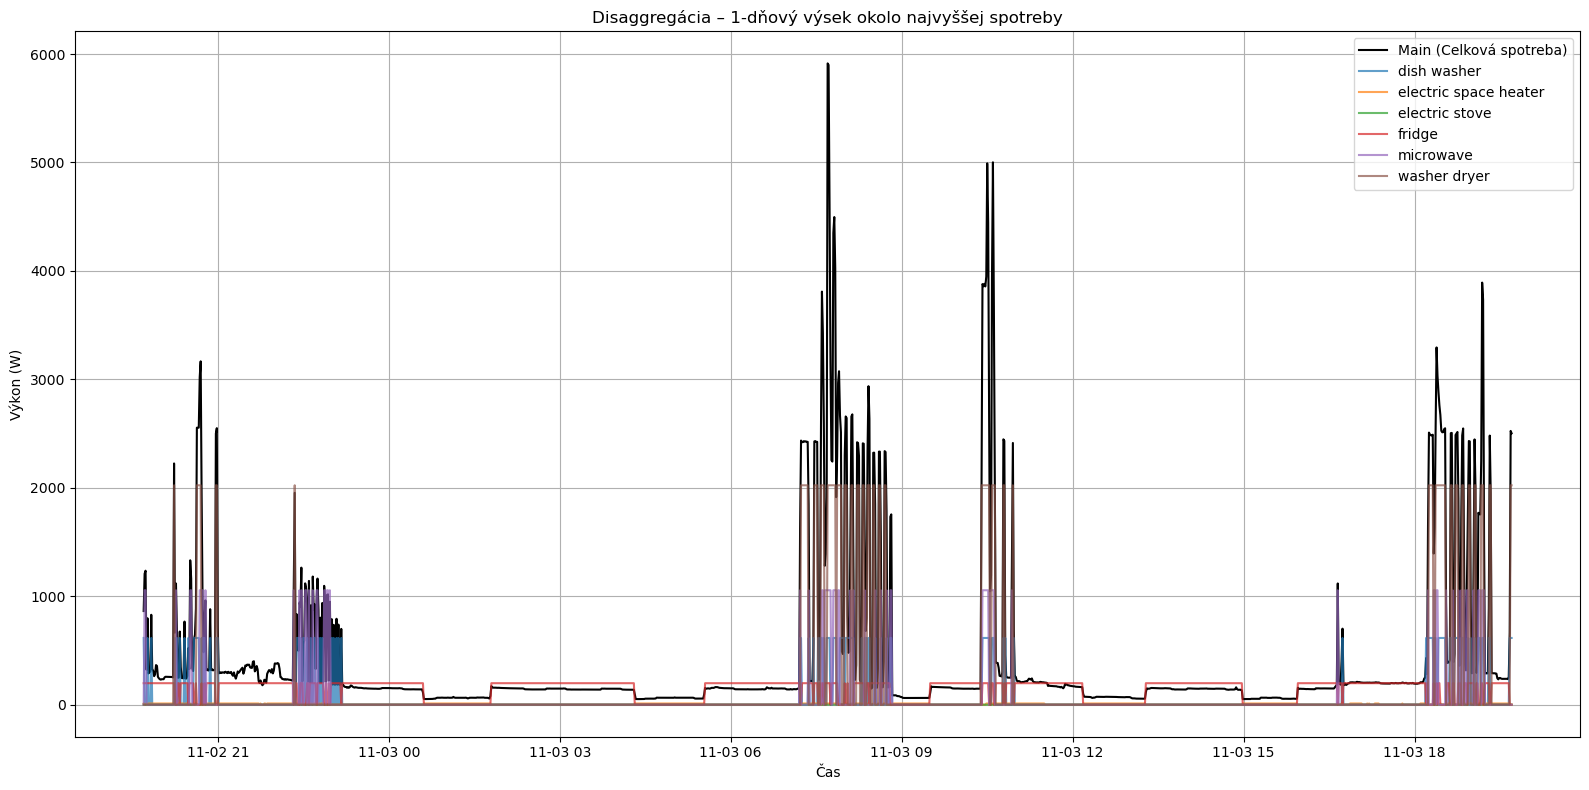

In [62]:
# Nájdeme čas s najvyššou spotrebou
peak_time = df_test.loc[df_test['main'].idxmax(), 'timestamp']

# Vymedzíme 1-dňový úsek okolo toho bodu (0.5 dňa pred a po)
start_peak_window = peak_time - pd.Timedelta(days=0.5)
end_peak_window = peak_time + pd.Timedelta(days=0.5)

# Vytvoríme výrez
mask_peak = (df_test['timestamp'] >= start_peak_window) & (df_test['timestamp'] <= end_peak_window)
df_peak = df_test[mask_peak].copy()
disagg_peak = disaggregated_test_df[mask_peak.values].copy()
disagg_peak['timestamp'] = df_peak['timestamp'].values

# Vizualizácia 1-dňového výseku okolo špičky
plt.figure(figsize=(16, 8))
plt.plot(df_peak['timestamp'], df_peak['main'], label='Main (Celková spotreba)', color='black')
for col in disagg_peak.columns.drop('timestamp'):
    plt.plot(disagg_peak['timestamp'], disagg_peak[col], label=col, alpha=0.7)

plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('Disaggregácia – 1-dňový výsek okolo najvyššej spotreby')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

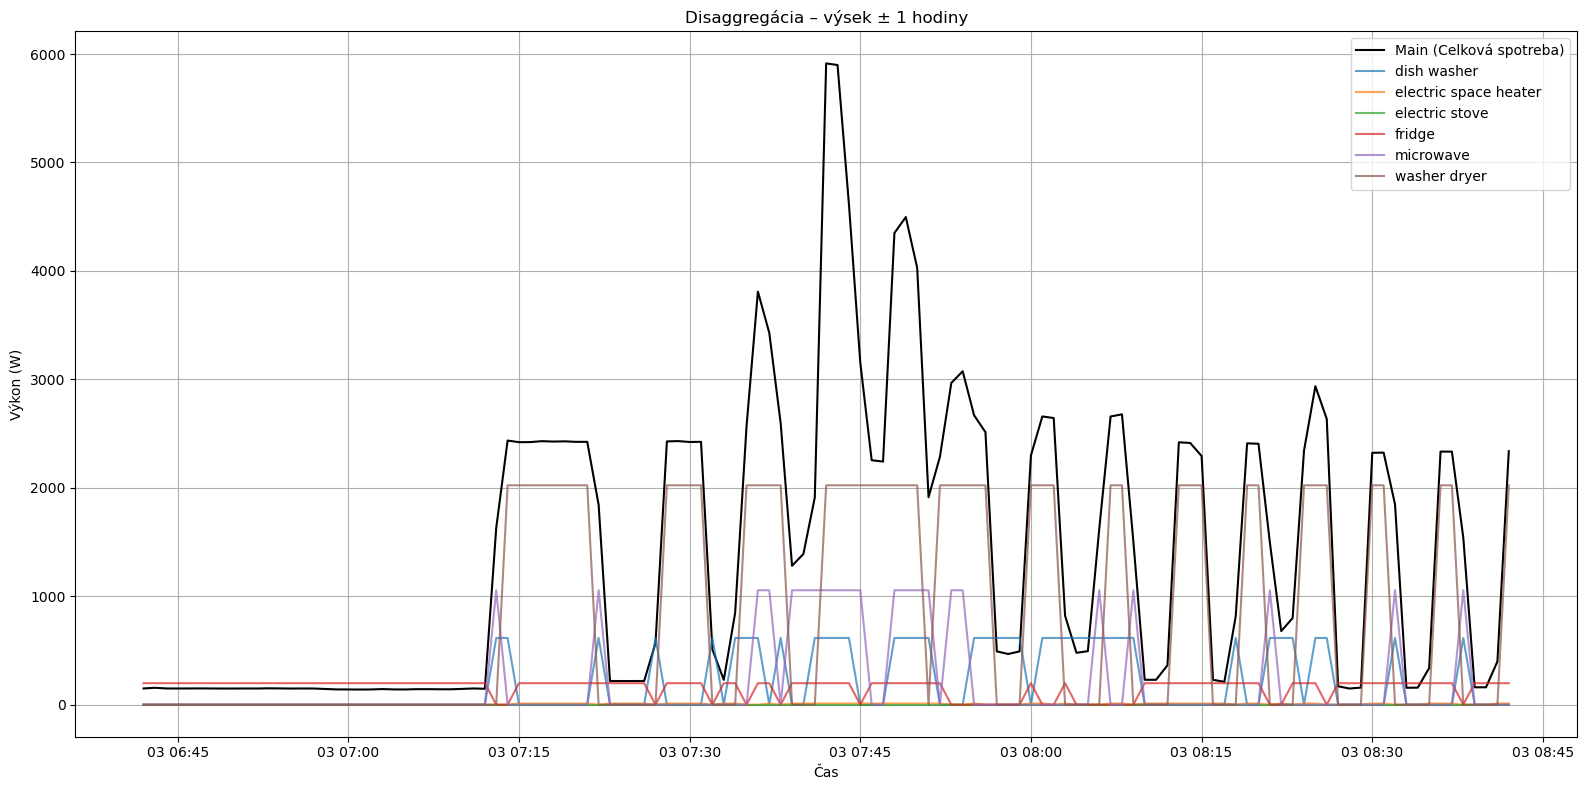

In [65]:
# Nájdeme čas najvyššej spotreby
peak_time = df_test.loc[df_test['main'].idxmax(), 'timestamp']

# Výrez: 3 hodiny pred a 3 hodiny po
start_window = peak_time - pd.Timedelta(hours=1)
end_window = peak_time + pd.Timedelta(hours=1)

# Výber dát pre výsek
mask_peak6h = (df_test['timestamp'] >= start_window) & (df_test['timestamp'] <= end_window)
df_peak6h = df_test[mask_peak6h].copy()
disagg_peak6h = disaggregated_test_df[mask_peak6h.values].copy()
disagg_peak6h['timestamp'] = df_peak6h['timestamp'].values

# Vizualizácia
plt.figure(figsize=(16, 8))
plt.plot(df_peak6h['timestamp'], df_peak6h['main'], label='Main (Celková spotreba)', color='black')
for col in disagg_peak6h.columns.drop('timestamp'):
    plt.plot(disagg_peak6h['timestamp'], disagg_peak6h[col], label=col, alpha=0.7)


plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('Disaggregácia – výsek ± 1 hodiny')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()